In [ ]:
import numpy as np
import rasterio
import rioxarray
import json
import geopandas as gpd
from pathlib import Path
from rasterio import features


CLASS_NAMES = [
    "kurgany_tselye", "kurgany_povrezhdennye",
    "fortifikatsii", "gorodishcha", "arkhitektury",
    "finds_points", "object_poly",
]

#Сопоставление числа обьектам, чтобы создавать пиксельную маску из чисел где 0 - ничего, i - номер класса
#Не факт что это правильно, ибо нейронка может неправильно это воспринять но пока так
CLASS_MAPPING = {
    "курганы_целые": 1, "курганы_поврежденные": 2,
    "фортификации": 3, "городища": 4, "архитектуры": 5,
    "_FindsPoints": 6, "_ObjectPoly": 7,
}

def get_class_id(file_name): #определеям что за обьект по имени файла разметки
    for keyword, class_id in CLASS_MAPPING.items():
        if keyword in file_name:
            return class_id
    return 0

def process_region(region_path):
    region_path = Path(region_path)

    utm_path = region_path / "UTM.json"
    with open(utm_path, 'r') as f:
        utm_data = json.load(f)
    target_crs = utm_data['crs'].split('::')[-1] #В эти координаты переводим все
    if not target_crs.startswith("EPSG:"):
        target_crs = f"EPSG:{target_crs}"

    tif_files = []
    tif_files.extend(region_path.glob("*SpOR*/*.tiff"))
    tif_files.extend(region_path.glob("*Or*/*.tiff"))
    # Ищем все геоджесоны в папке разметки
    geojson_files = list(region_path.glob("*_разметка/*.geojson"))
    if not tif_files:
        print("Нету ортофоток")
        return
    if not tif_files or not geojson_files:
        print("А где данные")
        return
    #возьмем первую ортофотку
    example = tif_files[0]
    ref_ds = rioxarray.open_rasterio(example)
    ref_ds = ref_ds.rio.reproject(target_crs)
    rgb_mask = ref_ds.values.transpose(1, 2, 0) # (высота, ширина, (р, г, б))
    if rgb_mask.shape[2] > 3:
        rgb_mask = rgb_mask[:, :, :3] #там 4 канал лишний какой-то фулл 255 забит

    #СОЗДАНИЕ МНОГОКЛАССОВОЙ МАСКИ
    final_mask = np.zeros((ref_ds.rio.height, ref_ds.rio.width), dtype='uint8')
    for g_file in geojson_files:
        if ("SpOR" in str(g_file) and "SpOR" in str(example)) or ("Or" in str(g_file) and "Or" in str(example)): #пока работает токо с ортофотками
            gdf = gpd.read_file(g_file)
            #переводим вектор в ту же систему координат, что и растр
            gdf = gdf.to_crs(target_crs)
            class_id = get_class_id(g_file.name)
            #рисуем объекты этого файла на маске
            file_mask = features.rasterize(
                [(shape, class_id) for shape in gdf.geometry],
                out_shape=(ref_ds.rio.height, ref_ds.rio.width),
                transform=ref_ds.rio.transform(),
                fill=0,
                dtype='uint8'
            )
            final_mask = np.maximum(final_mask, file_mask)
    unet_dir = region_path / "unet_dataset"
    unet_dir.mkdir(exist_ok=True)

    np.save(unet_dir / "image.npy", rgb_mask)
    np.save(unet_dir / "mask.npy", final_mask)



ModuleNotFoundError: No module named 'src'

In [18]:
import os
print("Текущая директория:", os.getcwd())
print("Путь к скрипту:", "/home/kadafi/prog/archaeology-segmentation/src/utils/io.py")
print("Пути поиска:", sys.path)

Текущая директория: /home/kadafi/prog/archaeology-segmentation/notebooks
Путь к скрипту: /home/kadafi/prog/archaeology-segmentation/src/utils/io.py


NameError: name 'sys' is not defined

In [14]:
process_region("/home/kadafi/prog/archaeology-segmentation/data/raw/010_НОВЕНЬКОЕ")

/home/kadafi/prog/archaeology-segmentation/venv/lib/python3.12/site-packages/rasterio/features.py:364: ShapeSkipWarning: Invalid or empty shape None at index 0 will not be rasterized.
  warnings.warn(


(np.float64(-0.5), np.float64(1264.5), np.float64(827.5), np.float64(-0.5))

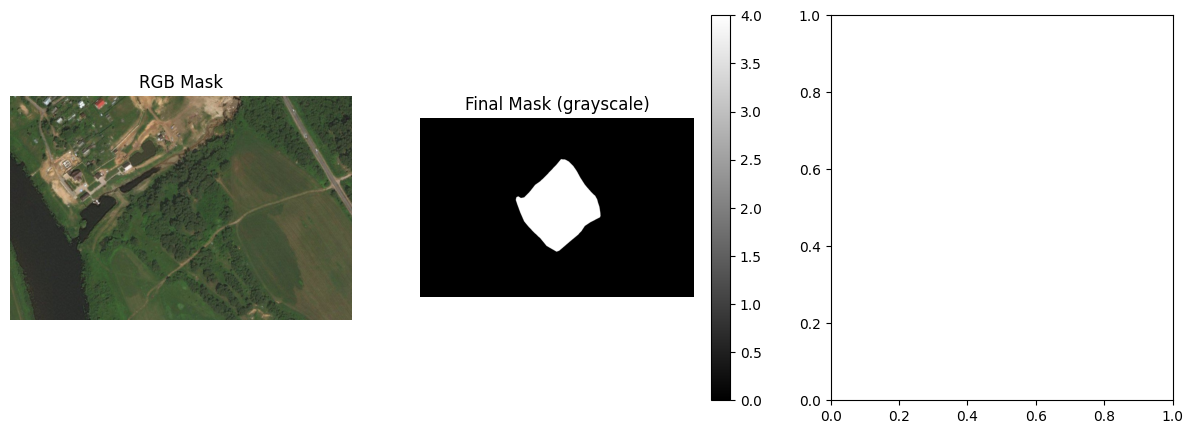

In [15]:
import numpy as np
import matplotlib.pyplot as plt

rgb_mask = np.load("/home/kadafi/prog/archaeology-segmentation/data/raw/010_НОВЕНЬКОЕ/unet_dataset/image.npy")
final_mask = np.load("/home/kadafi/prog/archaeology-segmentation/data/raw/010_НОВЕНЬКОЕ/unet_dataset/mask.npy")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb_mask)
axes[0].set_title("RGB Mask")
axes[0].axis('off')
if len(final_mask.shape) == 2:
    im = axes[1].imshow(final_mask, cmap='gray')
    axes[1].set_title("Final Mask (grayscale)")
    plt.colorbar(im, ax=axes[1])
else:
    axes[1].imshow(final_mask)
    axes[1].set_title("Final Mask")

axes[1].axis('off')

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2



class ArchaeologyDataset(Dataset):
    def __init__(self, root_dir, transform=None, split='train', valid_regions=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.image_paths = []
        self.mask_paths = []
        for dataset_dir in self.root_dir.glob("*/unet_dataset"):
            img_path = dataset_dir / "image.npy"
            mask_path = dataset_dir / "mask.npy"
            
            if img_path.exists() and mask_path.exists():
                # Определяем название региона (родительская папка)
                region_name = dataset_dir.parent.name
                 # 2. Разделение на трейн/тест
                if valid_regions is not None:
                    if split == 'train' and region_name not in valid_regions:
                        self.image_paths.append(img_path)
                        self.mask_paths.append(mask_path)
                    elif split == 'val' and region_name in valid_regions:
                        self.image_paths.append(img_path)
                        self.mask_paths.append(mask_path)
                else:
                    # Если список валидации не указан, кладем всё в трейн (для первого теста)
                    self.image_paths.append(img_path)
                    self.mask_paths.append(mask_path)
                    
        print(f"Найдено {len(self.image_paths)} изображений для {split}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        
        # Загружаем numpy массивы. ОЗУ расходуется только на этот один снимок
        image = np.load(img_path)  # Shape: (H, W, 3), dtype: uint8
        mask = np.load(mask_path)  # Shape: (H, W), dtype: uint8
        
        # Нормализация изображения (опционально, лучше делать в трансформах)
        # image = image.astype(np.float32) / 255.0

        # 4. АУГМЕНТАЦИИ
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Если трансформов нет, просто переводим в тензор
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()
            
        return image, mask
